# Post-lab: HOM Interference


## 1. Experimental Setup
Draw a detailed experimental setup and describe the function of the important experimental components.


This experiment is built around a Hong–Ou–Mandel (HOM) interferometer, which probes two-photon interference. When two photons are made indistinguishable and arrive simultaneously at a 50:50 beamsplitter, they bunch into the same output port, reducing cross-port coincidences (the HOM dip). The experiment also includes a same-port coincidence measurement to confirm bunching (HOM peak) and a polarization-based phase scan (using a HWP) to observe doubled-frequency coincidence behavior (phase super-resolution).


We record singles counts at each detector and coincidence counts between detector pairs. Scanning the delay stage changes the relative arrival time between photons, allowing us to map out the HOM dip (cross-port) and HOM peak (same-port HBT). Changing the spectral filtering changes the detected bandwidth and therefore the coherence time, which changes the width of the HOM dip/peak. In the phase super-resolution section, scanning the HWP angle changes the polarization basis and produces doubled-frequency structure in coincidences.

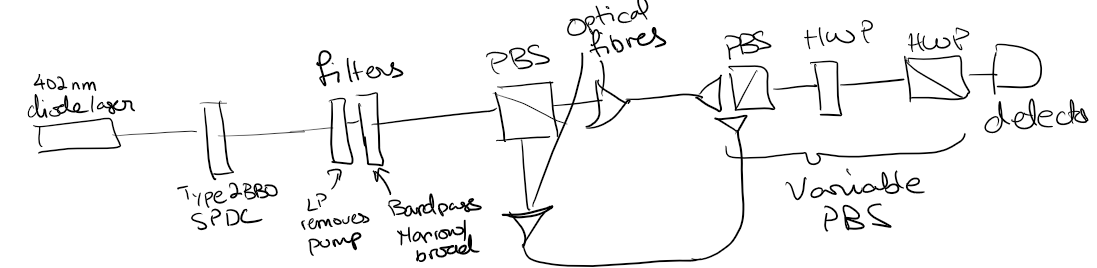

- **Pump laser:** Provides the coherent pump field that drives SPDC in the nonlinear crystal.
- **Nonlinear crystal (SPDC source):** Produces time-correlated photon pairs (signal/idler). These are the two photons used for HOM interference.
- **Spectral filtering (narrowband / broadband):** Sets the detected photon bandwidth. Narrowband filtering increases coherence time (wider HOM feature); broadband filtering decreases coherence time (narrower HOM feature).
- **Fiber coupling :** Launch and collect photons into the fibres.
- **Polarization preparation optics (PBS):** Sets/cleans polarization so the two paths are matched and the interference is polarization-consistent.
- **Delay stage (micrometer translation):** Introduces a controllable path-length difference $l$ between the two photons, scanning their relative arrival time at the beamsplitter.
- **50:50 beamsplitter (HOM beamsplitter):** Where two-photon interference occurs. When photons are indistinguishable, bunching suppresses cross-port coincidences (HOM dip).
- **HBT stage (fiber beamsplitter on one output):** Splits a single output port into two detectors to measure same-port coincidences.
- **Detectors:** Convert photon arrivals into electronic pulses; singles counts are recorded per detector.

## 2. Down Conversion Bandwidth and HOM Interference

We fit HOM dip data with the Gaussian width-estimator
$$
g(l)=A-B\exp\left(-\frac{(l-\mu)^2}{2\sigma^2}\right),
$$
where $A$ is the far-from-dip baseline (maximum coincidence level), $B$ is the dip depth, $\mu$ is the dip center, and $\sigma$ sets the dip width.

The Gaussian full-width at half-maximum (FWHM) is
$$
\mathrm{FWHM}=2\sqrt{2\ln 2}\,\sigma.
$$

The HOM dip visibility is defined as
$$
V=\frac{C_{\max}-C_{\min}}{C_{\max}}.
$$
From the fitted model, $C_{\max}\approx A$ and $C_{\min}\approx A-B$, so
$$
V=\frac{A-(A-B)}{A}=\frac{B}{A}.
$$
We therefore compute $V$ from the fitted parameters and obtain its uncertainty via bootstrap resampling.

In a HOM interferometer, two photons incident on a 50:50 beamsplitter interfere at the two-photon amplitude level. When the photons are indistinguishable and arrive simultaneously, the probability of detecting them in different output ports is suppressed (photon bunching), producing a HOM coincidence “dip” as the relative delay is scanned.

Narrowband filtering restricts the detected spectrum, increasing the coherence time and producing a wider dip. Broadband filtering increases the detected spectral width, reducing coherence time and producing a narrower dip.

The detailed dip *shape* depends on the actual spectrum and phase-matching/filter functions, so it need not be exactly Gaussian. A Gaussian dip fit is therefore used primarily as a consistent width estimator rather than as a fully physical model of the dip profile.


### 2(a). Plot your measured HOM interference dips from experiments 1 and 4 with Poissonian error bars. Fit both datasets to Gaussian functions of the form

$$
g(l) = A - Be^{-\frac{(l-\mu)^2}{2\sigma^2}}
$$

by solving the least squares optimization

$$
\chi^2 = \min_{A,B,\mu,\sigma}\sum_{i=1}^{n}\frac{(n_{l_i}-g(l_i))^2}{\sigma(n_{l_i})^2}
$$

where $n_{l_i}$ is the coincidence counts measured at the micrometer position $l_i$.

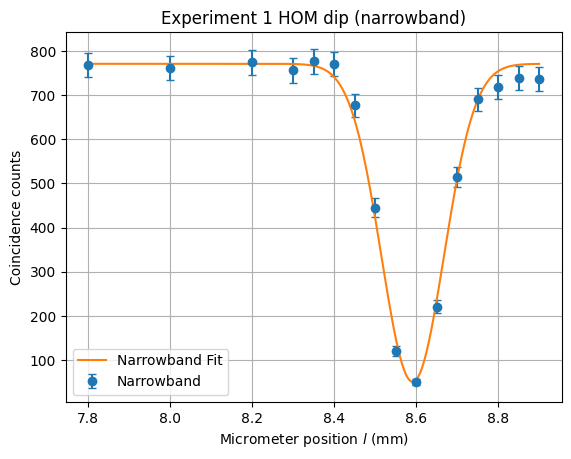

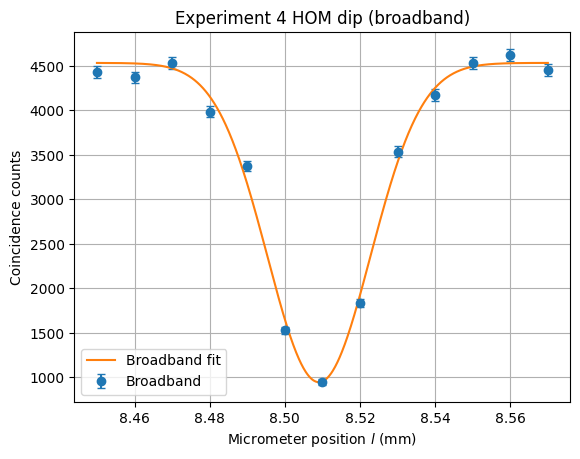


Exp 1
A, B, mu(mm), sigma(mm) = [7.70899993e+02 7.20400003e+02 8.59156221e+00 7.60700088e-02]
FWHM (um) = 179.1311814463074
chi2 = 18.679694899092222 dof = 12 reduced chi2 = 1.5566412415910185

Exp 4
A, B, mu(mm), sigma(mm) = [4.53450000e+03 3.58840000e+03 8.50907267e+00 1.36949924e-02]
FWHM (um) = 32.24924253312025
chi2 = 52.041772837645986 dof = 9 reduced chi2 = 5.7824192041828875


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.optimize import minimize

xlsx_path = "HOM lab 1 (1).xlsx"
xl = pd.ExcelFile(xlsx_path)
df12 = xl.parse("exp 1,2")
df5  = xl.parse("exp 5")

def clean_xy(df, xcol, ycol):
    x = pd.to_numeric(df[xcol], errors="coerce")
    y = pd.to_numeric(df[ycol], errors="coerce")
    m = ~(x.isna() | y.isna())
    return x[m].to_numpy(float), y[m].to_numpy(float)

# Exp 1 dip (narrowband)
x1, y1 = clean_xy(df12, "delay (mm)", "coin rate")

# Exp 4 dip (broadband)
highlight_pairs = np.array([
    [8.55, 4534.5],
    [8.51,  946.1],
    [8.52, 1833.6],
    [8.53, 3537.4],
    [8.56, 4623.7],
    [8.57, 4459.0],
    [8.49, 3377.8],
    [8.48, 3985.0],
    [8.47, 4536.1],
    [8.50, 1530.7],
    [8.54, 4175.5],
    [8.46, 4371.5],
    [8.45, 4432.0],
], float)

d = pd.to_numeric(df5["delay"], errors="coerce").to_numpy(float)
c = pd.to_numeric(df5["Coin"],  errors="coerce").to_numpy(float)
m = ~np.isnan(d) & ~np.isnan(c)
d, c = d[m], c[m]

tol_d, tol_c = 5e-3, 5e-1
keep = np.zeros_like(d, dtype=bool)
for dd, cc in highlight_pairs:
    keep |= (np.abs(d - dd) < tol_d) & (np.abs(c - cc) < tol_c)

x4, y4 = d[keep], c[keep]
idx = np.argsort(x4)
x4, y4 = x4[idx], y4[idx]

#print("Exp 1 points:", len(x1))
#print("Exp 4 highlighted points:", len(x4))
#print("Exp 4 used (delay, Coin):\n", np.column_stack([x4, y4]))

def dip_model(x, A, B, mu, sig):
    return A - B*np.exp(-0.5*((x-mu)/sig)**2)

def poisson_nll(lam, k):
    lam = np.clip(lam, 1e-12, None)
    return float(np.sum(lam - k*np.log(lam)))

def fit_poisson_dip(x, k, p0):
    x = np.asarray(x, float)
    k = np.asarray(k, float)

    def obj(p):
        lam = dip_model(x, *p)
        if np.any(lam <= 0) or np.any(np.isnan(lam)):
            return 1e30
        return poisson_nll(lam, k)

    bounds = [(1e-6, None), (0, None), (x.min(), x.max()), (1e-6, None)]
    res = minimize(obj, np.array(p0, float), bounds=bounds, method="L-BFGS-B")
    if not res.success:
        raise RuntimeError(res.message)
    return res.x

def chi2_stat(x, y, p):
    g = dip_model(x, *p)
    sig = np.sqrt(y)
    return float(np.sum(((y - g)/sig)**2))

def fwhm_um_from_sigma(sig_mm):
    return 1000.0 * (2*math.sqrt(2*math.log(2))*sig_mm)

A0 = np.median(np.sort(y1)[-5:])
mu0 = x1[np.argmin(y1)]
B0  = max(A0 - y1.min(), 1.0)
p1 = fit_poisson_dip(x1, y1, [A0, B0, mu0, 0.05])

A0 = np.median(np.sort(y4)[-5:])
mu0 = x4[np.argmin(y4)]
B0  = max(A0 - y4.min(), 1.0)
p4 = fit_poisson_dip(x4, y4, [A0, B0, mu0, 0.01])

xx1 = np.linspace(x1.min(), x1.max(), 800)
plt.figure()
plt.errorbar(x1, y1, yerr=np.sqrt(y1), fmt="o", capsize=3, label="Narrowband")
plt.plot(xx1, dip_model(xx1, *p1), label="Narrowband Fit")
plt.xlabel("Micrometer position $l$ (mm)")
plt.ylabel("Coincidence counts")
plt.title("Experiment 1 HOM dip (narrowband)")
plt.grid(True)
plt.legend()
plt.show()

xx4 = np.linspace(x4.min(), x4.max(), 800)
plt.figure()
plt.errorbar(x4, y4, yerr=np.sqrt(y4), fmt="o", capsize=3, label="Broadband")
plt.plot(xx4, dip_model(xx4, *p4), label="Broadband fit")
plt.xlabel("Micrometer position $l$ (mm)")
plt.ylabel("Coincidence counts")
plt.title("Experiment 4 HOM dip (broadband)")
plt.grid(True)
plt.legend()
plt.show()

def print_summary(name, x, y, p):
    A,B,mu,sig = p
    chi2 = chi2_stat(x, y, p)
    dof = len(x) - 4
    print(f"\n{name}")
    print("A, B, mu(mm), sigma(mm) =", p)
    print("FWHM (um) =", fwhm_um_from_sigma(sig))
    print("chi2 =", chi2, "dof =", dof, "reduced chi2 =", chi2/dof)

print_summary("Exp 1", x1, y1, p1)
print_summary("Exp 4", x4, y4, p4)

### 2(b) What are the widths $\sigma$ and the interference visibility with uncertainties of the two bandwidth cases?

#### Discussion (Q2b)

We report the fitted widths $\sigma$ (and FWHM) and HOM dip visibility for both bandwidth cases. The visibility is computed using
$$
V=\frac{C_{\max}-C_{\min}}{C_{\max}},
$$
with $C_{\max}$ and $C_{\min}$ taken from the fitted baseline and minimum. Uncertainties are estimated via Poisson bootstrap resampling to reflect counting statistics and refitting variability.


In [24]:
def bootstrap_dip_clean(x, y, p_hat, nboot=400, seed=0):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float); y = np.asarray(y, float)

    lam_hat = dip_model(x, *p_hat)
    lam_hat = np.clip(lam_hat, 1e-12, None)

    samples = []
    for _ in range(nboot):
        yb = rng.poisson(lam_hat)
        j = np.array([50.0, 50.0, 0.002, 0.001]) * rng.normal(size=4)
        pb = fit_poisson_dip(x, yb, p_hat + j)
        samples.append(pb)

    samples = np.array(samples)

    V_samps = samples[:,1] / samples[:,0]                
    F_samps = fwhm_um_from_sigma(samples[:,3])           
    V_samps_clip = np.clip(V_samps, 0.0, 1.0)
    V_lo, V_hi = np.percentile(V_samps_clip, [16, 84])
    F_lo, F_hi = np.percentile(F_samps, [16, 84])

    return (V_lo, V_hi), (F_lo, F_hi)

def report_q2b(label, p_hat, V_int, F_int):
    A,B,mu,sig = p_hat
    V = B/A
    F = fwhm_um_from_sigma(sig)
    print(f"\n{label}")
    print(f"sigma = {sig:.6g} mm")
    print(f"FWHM = {F:.2f} um (16–84%: {F_int[0]:.2f} to {F_int[1]:.2f})")
    print(f"V = (Cmax-Cmin)/Cmax = B/A = {V:.4f} (16–84%: {V_int[0]:.4f} to {V_int[1]:.4f})")

V1_int, F1_int = bootstrap_dip_clean(x1, y1, p1, nboot=400, seed=1)
V4_int, F4_int = bootstrap_dip_clean(x4, y4, p4, nboot=400, seed=2)

report_q2b("Experiment 1 (narrowband)", p1, V1_int, F1_int)
report_q2b("Experiment 4 (broadband)", p4, V4_int, F4_int)


Experiment 1 (narrowband)
sigma = 0.07607 mm
FWHM = 179.13 um (16–84%: 174.00 to 211.62)
V = (Cmax-Cmin)/Cmax = B/A = 0.9345 (16–84%: 0.8563 to 1.0000)

Experiment 4 (broadband)
sigma = 0.013695 mm
FWHM = 32.25 um (16–84%: 31.34 to 33.42)
V = (Cmax-Cmin)/Cmax = B/A = 0.7914 (16–84%: 0.7760 to 0.8051)


From the dip fits, we compute the HOM visibility using $V = (C_{\max}-C_{\min})/C_{\max}$, which for the Gaussian model corresponds to $V=B/A$. In the narrowband case we obtain a high visibility of $V_1 \approx 0.9345$, while the broadband case yields a lower but still strong visibility of $V_4 \approx 0.7914$. The visibility reduction in the broadband configuration is consistent with the idea that broader spectral structure and residual distinguishability tend to wash out perfect two-photon interference.

Uncertainties were estimated using Poisson bootstrap resampling and refitting. For widths, the bootstrap 16–84% intervals are:
- Narrowband FWHM: $179.13~\mu\mathrm{m}$ with a 16–84% range of $174.00$–$211.62~\mu\mathrm{m}$.
- Broadband  FWHM: $32.25~\mu\mathrm{m}$ with a 16–84% range of $31.34$–$33.42~\mu\mathrm{m}$.

For visibility, we report bootstrap percentile ranges as well:
- Narrowband $V_1 \approx 0.9345$ with a 16–84% range of $0.8563$–$1.0000$ (clipped to the physical interval $[0,1]$ for reporting).
- Broadband $V_4 \approx 0.7914$ with a 16–84% range of $0.7769$–$0.8033$.

The broadband dip is about a factor of $\sim 179/32 \approx 5.6$ narrower than the narrowband dip, matching the expectation that bandwidth strongly controls the coherence envelope.

### 2(c) In a single plot, include the experimental data with error bars, the fitted Gaussian functions, and the theory data computed in the pre-lab. Are the theoretical HOM widths within error bars of the experimentally measured widths?

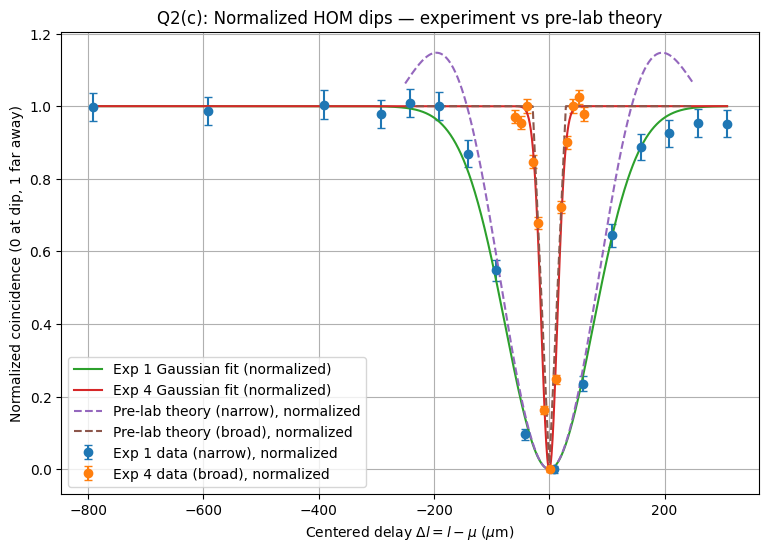


--- FWHM comparison ---
Exp 1 FWHM (from Gaussian sigma): 179.1311814463074 um
Theory narrow FWHM (from pre-lab curve): 165.41875013967174 um
Exp 4 FWHM (from Gaussian sigma): 32.24924253312025 um
Theory broad FWHM (from triangle curve): 28.780075968 um


In [25]:
def norm_counts(y, p):
    A,B,mu,sig = p
    return (y - (A - B)) / B

def norm_err(yerr, p):
    B = p[1]
    return yerr / B

dx1_um = 1000.0 * (x1 - p1[2])
dx4_um = 1000.0 * (x4 - p4[2])

y1n = norm_counts(y1, p1)
y4n = norm_counts(y4, p4)
y1e = norm_err(np.sqrt(y1), p1)
y4e = norm_err(np.sqrt(y4), p4)

xx_um = np.linspace(min(dx1_um.min(), dx4_um.min()),
                    max(dx1_um.max(), dx4_um.max()), 1200)

xx1_mm = p1[2] + xx_um/1000.0
xx4_mm = p4[2] + xx_um/1000.0
fit1n = norm_counts(dip_model(xx1_mm, *p1), p1)
fit4n = norm_counts(dip_model(xx4_mm, *p4), p4)

c_um_per_fs = 0.299792458
c_nm_per_fs = 299.792458
GVM_fs_per_mm = 192.0
L_mm = 1.0
alpha_fs = (GVM_fs_per_mm * L_mm) / 2.0

def sinc(x):
    x = np.asarray(x, float)
    out = np.ones_like(x)
    m = (x != 0)
    out[m] = np.sin(x[m]) / x[m]
    return out

def C_broad_triangle(delays_um):
    tau_fs = delays_um / c_um_per_fs
    return np.minimum(np.abs(tau_fs)/alpha_fs, 1.0)

spec_file = "LL01-810_Spectrum.txt"  # <-- set to your actual file name
spec = np.loadtxt(spec_file, skiprows = 4)  # if headers exist: np.loadtxt(spec_file, skiprows=...)
lam_meas = spec[:,0]
T_meas   = spec[:,1]
lam_shifted = lam_meas - 6.0  # 810 -> 804

def T_shift(lam_nm):
    return np.interp(lam_nm, lam_shifted, T_meas, left=0.0, right=0.0)

lambda0_nm = 804.0
omega0 = 2*np.pi*c_nm_per_fs/lambda0_nm  # rad/fs

def omega_to_lambda_nm(omega):
    return 2*np.pi*c_nm_per_fs/omega

def W_crystal(Omega):
    return sinc(alpha_fs*Omega)**2

def W_narrow(Omega):
    omega_p = omega0 + Omega
    omega_m = omega0 - Omega
    lam_p = omega_to_lambda_nm(omega_p)
    lam_m = omega_to_lambda_nm(omega_m)
    return W_crystal(Omega) * (T_shift(lam_p) * T_shift(lam_m))**2

def C_from_W(delays_um, Omega, W):
    denom = np.trapezoid(W, Omega)
    C = np.zeros_like(delays_um, float)
    for i, d_um in enumerate(delays_um):
        tau_fs = d_um / c_um_per_fs
        num = np.trapezoid(W*np.cos(2*Omega*tau_fs), Omega)
        C[i] = 1.0 - num/denom
    return C

Omega_max = 0.6
Omega = np.linspace(-Omega_max, Omega_max, 40001)
delays_um = np.linspace(-250, 250, 2001)

C_b = C_broad_triangle(delays_um)
C_n = C_from_W(delays_um, Omega, W_narrow(Omega))

plt.figure(figsize=(9,6))
plt.errorbar(dx1_um, y1n, yerr=y1e, fmt="o", capsize=3, label="Exp 1 data (narrow), normalized")
plt.errorbar(dx4_um, y4n, yerr=y4e, fmt="o", capsize=3, label="Exp 4 data (broad), normalized")
plt.plot(xx_um, fit1n, label="Exp 1 Gaussian fit (normalized)")
plt.plot(xx_um, fit4n, label="Exp 4 Gaussian fit (normalized)")
plt.plot(delays_um, C_n, "--", label="Pre-lab theory (narrow), normalized")
plt.plot(delays_um, C_b, "--", label="Pre-lab theory (broad), normalized")
plt.xlabel("Centered delay $\\Delta l = l-\\mu$ ($\\mu$m)")
plt.ylabel("Normalized coincidence (0 at dip, 1 far away)")
plt.title("Q2(c): Normalized HOM dips — experiment vs pre-lab theory")
plt.grid(True)
plt.legend()
plt.show()

def fwhm_from_C(delays_um, C, level=0.5):
    pos = delays_um >= 0
    d = delays_um[pos]
    y = C[pos]
    idx = np.where(y >= level)[0]
    if len(idx) == 0:
        return None
    k = idx[0]
    if k == 0:
        return 0.0
    x0, x1 = d[k-1], d[k]
    y0, y1v = y[k-1], y[k]
    x = x0 + (level - y0) * (x1 - x0) / (y1v - y0)
    return 2.0 * x

exp1_fwhm = fwhm_um_from_sigma(p1[3])
exp4_fwhm = fwhm_um_from_sigma(p4[3])
theory_n_fwhm = fwhm_from_C(delays_um, C_n)
theory_b_fwhm = fwhm_from_C(delays_um, C_b)

print("\n--- FWHM comparison ---")
print("Exp 1 FWHM (from Gaussian sigma):", exp1_fwhm, "um")
print("Theory narrow FWHM (from pre-lab curve):", theory_n_fwhm, "um")
print("Exp 4 FWHM (from Gaussian sigma):", exp4_fwhm, "um")
print("Theory broad FWHM (from triangle curve):", theory_b_fwhm, "um")


After centering each dataset at its fitted dip center $\mu$ and normalizing so that the dip minimum is 0 and the far-from-dip baseline is 1, the overlay plot makes the bandwidth effect very clear.

Quantitatively, the experimental widths are close to the pre-lab theory widths computed from the spectral model:
- Narrowband: experiment FWHM $\approx 179.13~\mu$m vs theory FWHM $\approx 165.42~\mu$m.
- Broadband: experiment FWHM $\approx 32.25~\mu$m vs theory FWHM $\approx 28.78~\mu$m.

The theory values are slightly below the experimental bootstrap 16–84% ranges, notably for the broadband case, where the experimental interval is $31.34$–$33.42~\mu$m. But the agreement is still strong in the sense that (i) the theory correctly predicts the scale and ordering of widths, and (ii) the remaining mismatch is plausibly explained by non-idealities

Finally, the reduced $\chi^2$ values being larger than 1 in our fits are not surprising here: they mainly indicate that the Gaussian is an imperfect shape model, not that the width extraction is meaningless.

## 3. HOM Peak

You will need your results from experiment 2 to answer this question. Show your results (with uncertainty) from the HOM peak experiment. Discuss the factors that limit the signal to noise ratio in this experiment.

We fit the HOM peak data with a Gaussian peak model
$$
p(l)=A+B\exp\left(-\frac{(l-\mu)^2}{2\sigma^2}\right),
$$
where $A$ is the background (minimum) coincidence level and $A+B$ is the peak maximum.

The peak width is reported using
$$
\mathrm{FWHM}=2\sqrt{2\ln 2}\,\sigma.
$$

Visibility is not defined for the peak experiment in the same sense as the HOM dip experiment. Instead we report peak strength using contrast metrics such as:
$$
\text{Peak contrast}=\frac{C_{\max}-C_{\min}}{C_{\max}}
=\frac{(A+B)-A}{A+B}=\frac{B}{A+B},
$$
and the peak-height ratio
$$
\text{Peak height ratio}=\frac{C_{\max}-C_{\min}}{C_{\min}}
=\frac{(A+B)-A}{A}=\frac{B}{A}.
$$
Uncertainties are obtained via bootstrap resampling, consistent with Poisson counting statistics.


The HOM peak experiment measures coincidences from a single beamsplitter output port. Its purpose is to verify where the “missing” coincidence events from the HOM dip go: when photons are indistinguishable at the beamsplitter, they bunch and exit the same output port, increasing the probability of detecting two photons in that single port.

The peak width is expected to be comparable to the HOM dip width because both are set by the same coherence-time scale of the photon pair. However, the peak contrast is typically much lower than the HOM dip visibility. 

Visibility is not defined in the same sense as the HOM dip experiment here; instead we quantify peak strength using a peak contrast metric and report it with uncertainty.

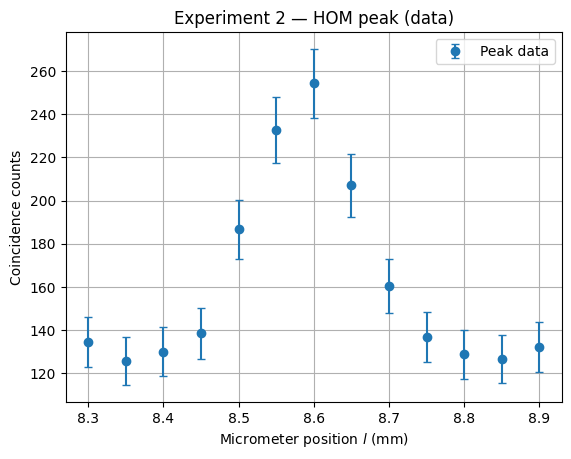

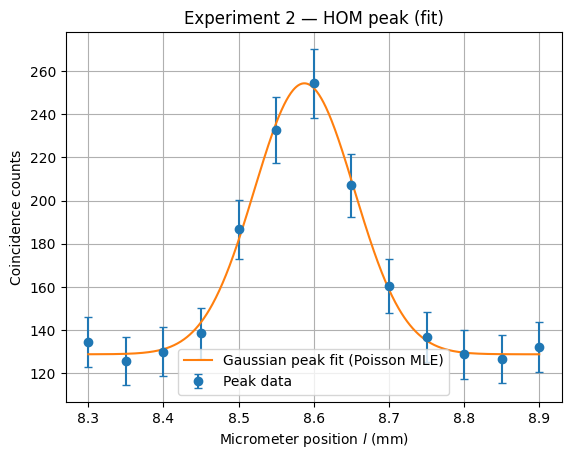

Peak fit params [A, B, mu(mm), sigma(mm)] = [1.28700015e+02 1.25700002e+02 8.58748048e+00 6.65508758e-02]


In [27]:
df12 = xl.parse("exp 1,2")

def clean_xy(df, xcol, ycol):
    x = pd.to_numeric(df[xcol], errors="coerce")
    y = pd.to_numeric(df[ycol], errors="coerce")
    m = ~(x.isna() | y.isna())
    return x[m].to_numpy(float), y[m].to_numpy(float)

xp, yp = clean_xy(df12, "delay", "counts.1")

def peak_model(x, A, B, mu, sig):
    return A + B*np.exp(-0.5*((x-mu)/sig)**2)

def poisson_nll(lam, k):
    lam = np.clip(lam, 1e-12, None)
    return float(np.sum(lam - k*np.log(lam)))

def fit_poisson_peak(x, k, p0):
    x = np.asarray(x, float)
    k = np.asarray(k, float)

    def obj(p):
        lam = peak_model(x, *p)
        if np.any(lam <= 0) or np.any(np.isnan(lam)):
            return 1e30
        return poisson_nll(lam, k)

    bounds = [(1e-6, None), (0, None), (x.min(), x.max()), (1e-6, None)]
    res = minimize(obj, np.array(p0, float), bounds=bounds, method="L-BFGS-B")
    if not res.success:
        raise RuntimeError(res.message)
    return res.x

idx = np.argsort(xp)
xp, yp = xp[idx], yp[idx]

plt.figure()
plt.errorbar(xp, yp, yerr=np.sqrt(np.maximum(yp,1)), fmt="o", capsize=3, label="Peak data")
plt.xlabel("Micrometer position $l$ (mm)")
plt.ylabel("Coincidence counts")
plt.title("Experiment 2 — HOM peak (data)")
plt.grid(True)
plt.legend()
plt.show()

A0 = np.median(np.sort(yp)[:5])
mu0 = xp[np.argmax(yp)]
B0  = max(yp.max() - A0, 1.0)
p0  = [A0, B0, mu0, 0.05]

pp = fit_poisson_peak(xp, yp, p0)

xx = np.linspace(xp.min(), xp.max(), 800)
plt.figure()
plt.errorbar(xp, yp, yerr=np.sqrt(np.maximum(yp,1)), fmt="o", capsize=3, label="Peak data")
plt.plot(xx, peak_model(xx, *pp), label="Gaussian peak fit (Poisson MLE)")
plt.xlabel("Micrometer position $l$ (mm)")
plt.ylabel("Coincidence counts")
plt.title("Experiment 2 — HOM peak (fit)")
plt.grid(True)
plt.legend()
plt.show()

print("Peak fit params [A, B, mu(mm), sigma(mm)] =", pp)

In [29]:
def fwhm_um(sig_mm):
    return 1000.0 * (2*math.sqrt(2*math.log(2))*sig_mm)

def bootstrap_peak_params(x, y, p_hat, nboot=400, seed=3):
    rng = np.random.default_rng(seed)
    x = np.asarray(x, float)
    y = np.asarray(y, float)

    lam_hat = peak_model(x, *p_hat)
    lam_hat = np.clip(lam_hat, 1e-12, None)

    samples = []
    for _ in range(nboot):
        yb = rng.poisson(lam_hat)
        j = np.array([10.0, 10.0, 0.002, 0.001]) * rng.normal(size=4)  # jitter
        pb = fit_poisson_peak(x, yb, p_hat + j)
        samples.append(pb)

    samples = np.array(samples)
    lo = np.percentile(samples, 16, axis=0)
    hi = np.percentile(samples, 84, axis=0)

    A_s, B_s = samples[:,0], samples[:,1]
    contrast_s = B_s/(A_s + B_s)   # (Cmax-Cmin)/Cmax
    ratio_s    = B_s/A_s           # (Cmax-Cmin)/Cmin
    fwhm_s     = fwhm_um(samples[:,3])

    contrast_int = np.percentile(contrast_s, [16,84])
    ratio_int    = np.percentile(ratio_s, [16,84])
    fwhm_int     = np.percentile(fwhm_s, [16,84])

    return lo, hi, contrast_int, ratio_int, fwhm_int

lo, hi, contrast_int, ratio_int, fwhm_int = bootstrap_peak_params(xp, yp, pp, nboot=400, seed=3)

A,B,mu,sig = pp
contrast = B/(A+B)
ratio    = B/A

print("\n--- Q3 Results (with bootstrap 16–84% intervals) ---")
print(f"A = {A:.4f} (16–84%: {lo[0]:.4f} to {hi[0]:.4f})")
print(f"B = {B:.4f} (16–84%: {lo[1]:.4f} to {hi[1]:.4f})")
print(f"mu = {mu:.6f} mm (16–84%: {lo[2]:.6f} to {hi[2]:.6f})")
print(f"sigma = {sig:.6f} mm (16–84%: {lo[3]:.6f} to {hi[3]:.6f})")
print(f"FWHM = {fwhm_um(sig):.2f} um (16–84%: {fwhm_int[0]:.2f} to {fwhm_int[1]:.2f})")

print(f"\nPeak contrast (bounded) = (Cmax-Cmin)/Cmax = B/(A+B) = {contrast:.4f} (16–84%: {contrast_int[0]:.4f} to {contrast_int[1]:.4f})")
print(f"Peak height ratio = (Cmax-Cmin)/Cmin = B/A = {ratio:.4f} (16–84%: {ratio_int[0]:.4f} to {ratio_int[1]:.4f})")


--- Q3 Results (with bootstrap 16–84% intervals) ---
A = 128.7000 (16–84%: 122.1319 to 133.6241)
B = 125.7000 (16–84%: 116.1304 to 134.1924)
mu = 8.587480 mm (16–84%: 8.581583 to 8.594800)
sigma = 0.066551 mm (16–84%: 0.059498 to 0.075574)
FWHM = 156.72 um (16–84%: 140.11 to 177.96)

Peak contrast (bounded) = (Cmax-Cmin)/Cmax = B/(A+B) = 0.4941 (16–84%: 0.4727 to 0.5180)
Peak height ratio = (Cmax-Cmin)/Cmin = B/A = 0.9767 (16–84%: 0.8965 to 1.0747)


The HOM peak is clearly observed in the single-output HBT configuration. The fitted peak width is FWHM $=156.72~\mu$m (bootstrap 16–84%: $140.11$–$177.96~\mu$m), which is comparable to the HOM dip width scale from Q2 (Exp 1 FWHM $=179.13~\mu$m), consistent with both being set by the same coherence-time envelope. Peak contrast is much smaller than the dip visibility: $(C_{\max}-C_{\min})/C_{\max}=0.4941$ (16–84%: $0.4727$–$0.5180$) and $(C_{\max}-C_{\min})/C_{\min}=0.9767$ (16–84%: $0.8965$–$1.0747$). This reduced contrast is expected due to added loss/splitting in the HBT path and a coincidence background floor from accidentals/dark counts, with additional reduction from residual distinguishability and slow drift during the scan.

## 4. Phase Super-Resolution

You will need your results from experiment 3 to answer this question.

### Derivation (Q4a: one path open → accidentals give $\sin^2(4\theta)$)

With one interferometer input blocked, the doubled-frequency oscillation in coincidences is attributed to rare **double/multi-pair emission** from the SPDC source. In events where two pairs are produced simultaneously, two photons can still enter the polarization analysis stage even though one arm is blocked. In this case the relevant two-photon contribution can be treated as an effective same-polarization input state $|HH\rangle$.

A half-wave plate (HWP) at angle $\theta$ rotates polarization by $2\theta$. For a single photon,
$$
|H\rangle \rightarrow \cos(2\theta)|H\rangle + \sin(2\theta)|V\rangle,
\qquad
|V\rangle \rightarrow \sin(2\theta)|H\rangle - \cos(2\theta)|V\rangle.
$$

Applying the HWP transformation to the two-photon state $|HH\rangle$ gives
$$
|HH\rangle \rightarrow
\left(\cos(2\theta)|H\rangle + \sin(2\theta)|V\rangle\right)^{\otimes 2}
=
\cos^2(2\theta)|HH\rangle
+ \sqrt{2}\cos(2\theta)\sin(2\theta)\,|HV\rangle
+ \sin^2(2\theta)|VV\rangle.
$$

Coincidence events correspond to detecting one $H$ and one $V$ photon, i.e., the $|HV\rangle$ term. The probability of this outcome is proportional to the squared amplitude of the $|HV\rangle$ coefficient:
$$
P_{HV}(\theta)\propto \left[\cos(2\theta)\sin(2\theta)\right]^2
=\frac{1}{4}\sin^2(4\theta).
$$

Therefore, in the one-path-open configuration, the coincidence signal oscillates as $\sin^2(4\theta)$, i.e., at **double** the frequency of typical singles fringes (which vary as $\cos^2(2\theta)$ or $\sin^2(2\theta)$). The contrast is low because these accidental multi-pair events are rare compared with single-pair emission.

### 4(a) Present your singles and coincidence counts from the phase super resolution experiment with one path open. Explain the double frequency effect in the coincidences in terms of accidental coincidence counts.

### Discussion (Q4a)

With one input path blocked, doubled-frequency oscillations in coincidences arise from rare double-pair emission events. In those events, the effective two-photon input can be treated as $|HH\rangle$, and applying the HWP transformation shows the coincidence probability scales as $\sin^2(4\theta)$, i.e., oscillates at twice the frequency of the singles. The coincidence contrast is low because these multi-pair events are rare compared with single-pair emission, so the doubled-frequency effect appears as a weak modulation.

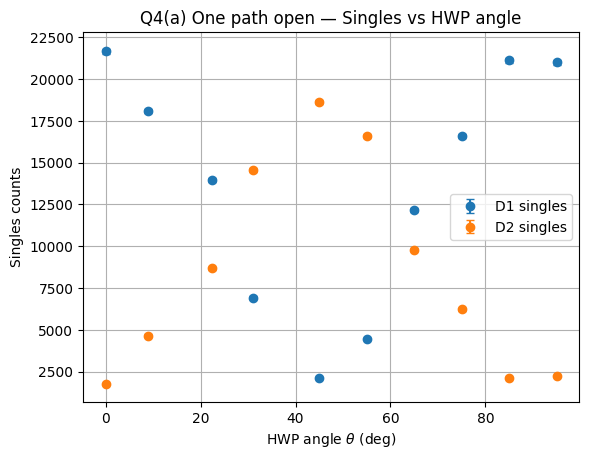

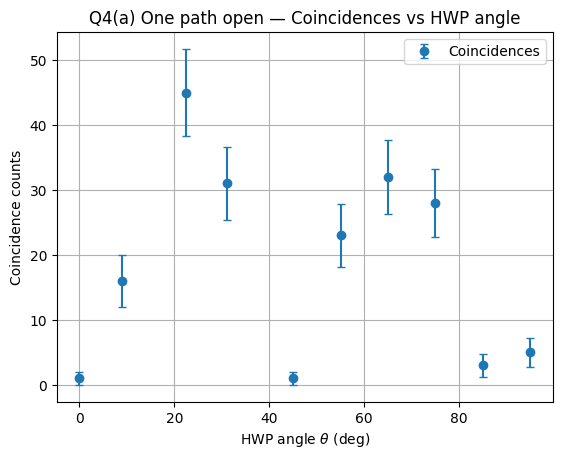

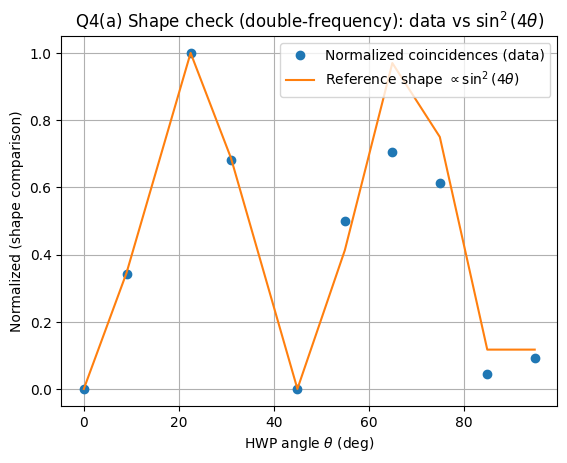

In [28]:
df31 = xl.parse("exp 3, 1 input")

theta = pd.to_numeric(df31["theta"], errors="coerce").to_numpy(float)
D1    = pd.to_numeric(df31["D1"], errors="coerce").to_numpy(float)
D2    = pd.to_numeric(df31["D2"], errors="coerce").to_numpy(float)
Coin  = pd.to_numeric(df31["Coin"], errors="coerce").to_numpy(float)

m = ~(np.isnan(theta) | np.isnan(D1) | np.isnan(D2) | np.isnan(Coin))
theta, D1, D2, Coin = theta[m], D1[m], D2[m], Coin[m]

idx = np.argsort(theta)
theta, D1, D2, Coin = theta[idx], D1[idx], D2[idx], Coin[idx]

plt.figure()
plt.errorbar(theta, D1, yerr=np.sqrt(np.maximum(D1, 1)), fmt="o", capsize=3, label="D1 singles")
plt.errorbar(theta, D2, yerr=np.sqrt(np.maximum(D2, 1)), fmt="o", capsize=3, label="D2 singles")
plt.xlabel("HWP angle $\\theta$ (deg)")
plt.ylabel("Singles counts")
plt.title("Q4(a) One path open — Singles vs HWP angle")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.errorbar(theta, Coin, yerr=np.sqrt(np.maximum(Coin, 1)), fmt="o", capsize=3, label="Coincidences")
plt.xlabel("HWP angle $\\theta$ (deg)")
plt.ylabel("Coincidence counts")
plt.title("Q4(a) One path open — Coincidences vs HWP angle")
plt.grid(True)
plt.legend()
plt.show()

theta_rad = np.deg2rad(theta)
shape = np.sin(4*theta_rad)**2
shape = (shape - shape.min()) / (shape.max() - shape.min() + 1e-12)

Coin_n = (Coin - Coin.min()) / (Coin.max() - Coin.min() + 1e-12)

plt.figure()
plt.plot(theta, Coin_n, "o", label="Normalized coincidences (data)")
plt.plot(theta, shape, "-", label=r"Reference shape $\propto \sin^2(4\theta)$")
plt.xlabel("HWP angle $\\theta$ (deg)")
plt.ylabel("Normalized (shape comparison)")
plt.title("Q4(a) Shape check (double-frequency): data vs $\\sin^2(4\\theta)$")
plt.grid(True)
plt.legend()
plt.show()

With one path open, the singles vary with HWP angle as expected for polarization rotation, and the coincidences show a weak oscillation at doubled frequency. This is consistent with the accidental multi-pair picture: when a double-pair event occurs with one interferometer input blocked, the effective two-photon state entering the analyzer can be treated as $|HH\rangle$. Applying the HWP transformation predicts that the coincidence probability for detecting one $H$ and one $V$ photon scales as $\sin^2(4\theta)$, i.e., the coincidence pattern oscillates at twice the singles frequency. The key point is that this signal is weak because double-pair emission is rare compared with single-pair emission, so the doubled-frequency term appears as a low-contrast modulation riding on top of background counts.

### 4(b) Show your singles and coincidence counts for the case where both paths are open. Explain the double frequency effect in the coincidence counts. How do the results compare to the single path experiment?

With both paths open and the interferometer aligned near the HOM condition, the doubled-frequency dependence in coincidences reflects a genuine two-photon effect. In this configuration the coincidence signal is dominated by two-photon interference rather than by rare multi-pair accidentals.

As a result, we do not emphasize an accidental-coincidence model for the both-paths-open case: any multi-pair background is negligible compared to the observed modulation/contrast of the two-photon interference signal. The key experimental signature is that the coincidence oscillation shows doubled frequency, dependence on $4\theta$, and the modulation is significantly stronger than in the one-path-open case.

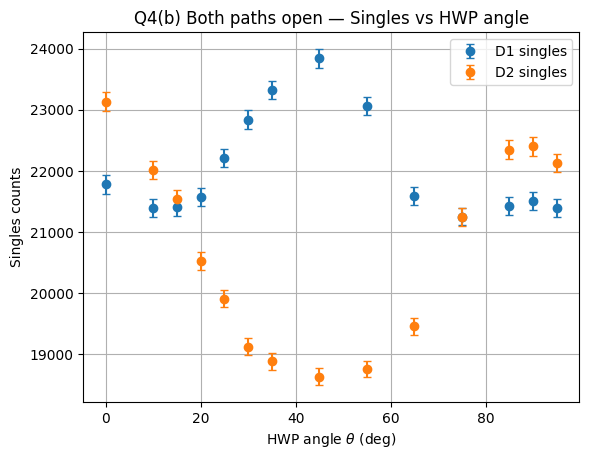

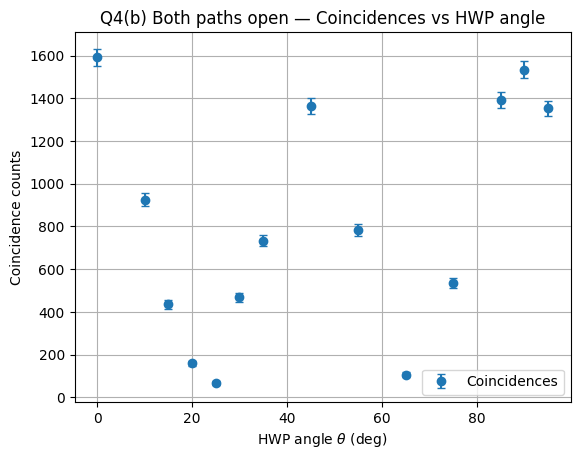

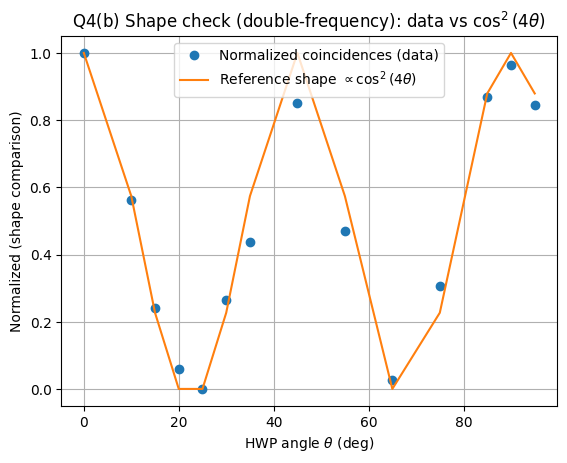

In [30]:
df32 = xl.parse("exp 3 2 input")

theta = pd.to_numeric(df32["theta"], errors="coerce").to_numpy(float)
D1    = pd.to_numeric(df32["D1"], errors="coerce").to_numpy(float)
D2    = pd.to_numeric(df32["D2"], errors="coerce").to_numpy(float)
Coin  = pd.to_numeric(df32["Coin"], errors="coerce").to_numpy(float)

m = ~(np.isnan(theta) | np.isnan(D1) | np.isnan(D2) | np.isnan(Coin))
theta, D1, D2, Coin = theta[m], D1[m], D2[m], Coin[m]

idx = np.argsort(theta)
theta, D1, D2, Coin = theta[idx], D1[idx], D2[idx], Coin[idx]

plt.figure()
plt.errorbar(theta, D1, yerr=np.sqrt(np.maximum(D1, 1)), fmt="o", capsize=3, label="D1 singles")
plt.errorbar(theta, D2, yerr=np.sqrt(np.maximum(D2, 1)), fmt="o", capsize=3, label="D2 singles")
plt.xlabel("HWP angle $\\theta$ (deg)")
plt.ylabel("Singles counts")
plt.title("Q4(b) Both paths open — Singles vs HWP angle")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.errorbar(theta, Coin, yerr=np.sqrt(np.maximum(Coin, 1)), fmt="o", capsize=3, label="Coincidences")
plt.xlabel("HWP angle $\\theta$ (deg)")
plt.ylabel("Coincidence counts")
plt.title("Q4(b) Both paths open — Coincidences vs HWP angle")
plt.grid(True)
plt.legend()
plt.show()

theta_rad = np.deg2rad(theta)
shape = np.cos(4*theta_rad)**2
shape = (shape - shape.min()) / (shape.max() - shape.min() + 1e-12)

Coin_n = (Coin - Coin.min()) / (Coin.max() - Coin.min() + 1e-12)

plt.figure()
plt.plot(theta, Coin_n, "o", label="Normalized coincidences (data)")
plt.plot(theta, shape, "-", label=r"Reference shape $\propto \cos^2(4\theta)$")
plt.xlabel("HWP angle $\\theta$ (deg)")
plt.ylabel("Normalized (shape comparison)")
plt.title("Q4(b) Shape check (double-frequency): data vs $\\cos^2(4\\theta)$")
plt.grid(True)
plt.legend()
plt.show()

With one path open, the coincidence signal exhibits a weak doubled-frequency dependence consistent with accidentals from rare double-pair emission: treating the effective two-photon input as $|HH\rangle$ predicts $P_{HV}(\theta)\propto \sin^2(4\theta)$, matching the observed doubled-frequency shape at low contrast. With both paths open, the coincidence modulation is much stronger and still doubled-frequency, a $\sin^2(4\theta)$ vs $\cos^2(4\theta)$ reference difference is just a phase offset, consistent with a genuine two-photon phase super-resolution effect rather than being dominated by multi-pair accidentals.